In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of FruitinAmazon.zip" /content/

In [3]:
!ls /content/

'Copy of FruitinAmazon.zip'   drive   sample_data


In [5]:
!unzip "/content/Copy of FruitinAmazon.zip" -d /content/dataset

Archive:  /content/Copy of FruitinAmazon.zip
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/dataset/FruitinAmazon/tes

In [8]:
!ls /content/dataset/FruitinAmazon

test  train


# Step 0: Setup Colab

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# Task 1: Data Understanding & Visualization

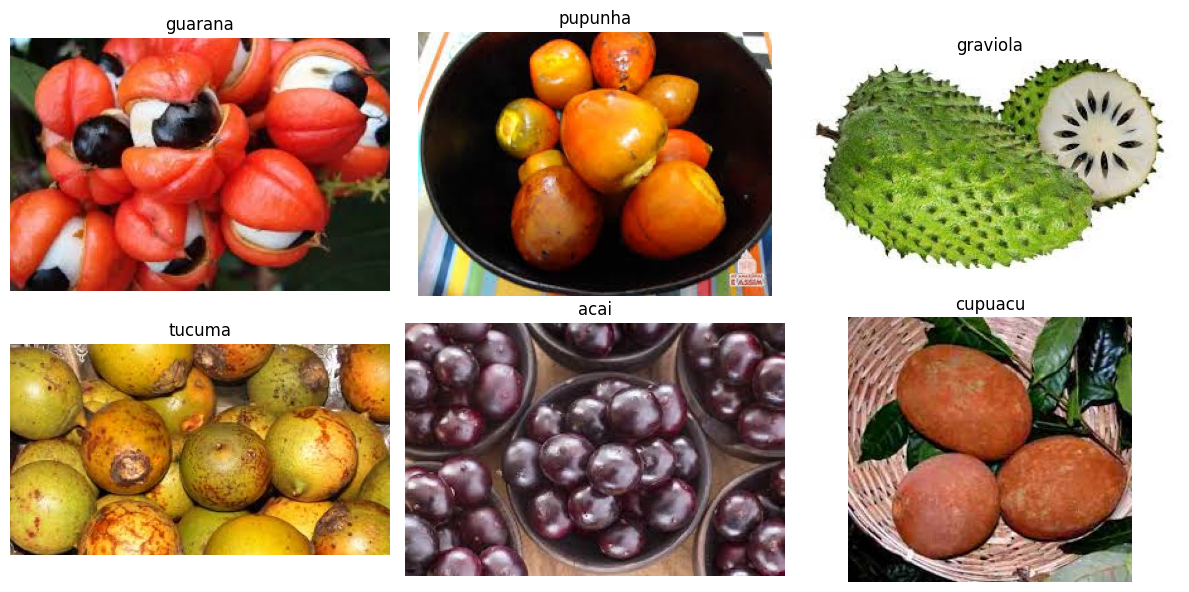

In [18]:


train_dir = "/content/dataset/FruitinAmazon/train"

classes = os.listdir(train_dir)

images = []
labels = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

plt.figure(figsize=(12, 6))

cols = 3
rows = (len(images) + cols - 1) // cols

for i in range(len(images)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Remove Corrupted Images

In [23]:
corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


Observation:

The dataset contains fruit images organized into separate class folders, which confirms that it is structured for supervised multi-class image classification. The sample images show clear visual differences in color, texture, and shape, but there are also variations in background, lighting, orientation, and image size. These variations make the dataset more realistic and help the CNN learn robust features.

# Task 2: Load & Preprocess Data

In [44]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/dataset/FruitinAmazon/train"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 2 Observation:

The images were successfully loaded from the directory using image_dataset_from_directory(), resized to 128 × 128 pixels, and grouped into batches. A validation split was also created from the training directory. After applying rescaling, pixel values were normalized to the range [0, 1], which helps improve training stability and model performance. This preprocessing step ensures that all images have a consistent size and format before being passed to the CNN model.

# Task 3: Build CNN Model

In [45]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 5: Train Model

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.1047 - loss: 2.6044

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 776ms/step - accuracy: 0.1111 - loss: 2.9566 - val_accuracy: 0.8333 - val_loss: 0.7736
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.2083 - loss: 2.1019 - val_accuracy: 0.2222 - val_loss: 1.5366
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.3889 - loss: 1.5160 - val_accuracy: 0.1111 - val_loss: 1.7155
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.3056 - loss: 1.4178 - val_accuracy: 0.3889 - val_loss: 1.5799
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.6250 - loss: 1.2154 - val_accuracy: 0.5000 - val_loss: 1.1310
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 450ms/step - accuracy: 0.5417 - loss: 1.0242 - val_accuracy: 0.6111 - val_loss: 1.3562
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 785ms/step - accuracy: 0.7639 - loss: 0.8708 - val_accuracy: 0.3889 - val_loss: 1.2656
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.8652 - loss: 0.6665

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 954ms/step - accuracy: 0.8611 - loss: 0.7016 - val_accuracy: 0.7778 - val_loss: 0.7511
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8924 - loss: 0.4517

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step - accuracy: 0.8333 - loss: 0.5300 - val_accuracy: 0.7778 - val_loss: 0.6778
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.9167 - loss: 0.3239 - val_accuracy: 0.5556 - val_loss: 0.9140
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8750 - loss: 0.3743

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.8750 - loss: 0.3606 - val_accuracy: 0.8333 - val_loss: 0.6053
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 1.0000 - loss: 0.1586 - val_accuracy: 0.8333 - val_loss: 0.7558
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9404 - loss: 0.2395

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 764ms/step - accuracy: 0.9306 - loss: 0.2501 - val_accuracy: 0.7778 - val_loss: 0.5545
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9502 - loss: 0.1598

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9444 - loss: 0.1753 - val_accuracy: 0.8333 - val_loss: 0.4474
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 1.0000 - loss: 0.0936 - val_accuracy: 0.6667 - val_loss: 0.8631
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9803 - loss: 0.1050

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.9722 - loss: 0.1091 - val_accuracy: 0.8889 - val_loss: 0.3518
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 1.0000 - loss: 0.0530 - val_accuracy: 0.8889 - val_loss: 0.3928
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - accuracy: 0.9861 - loss: 0.0587 - val_accuracy: 0.8889 - val_loss: 0.3743
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 1.0000 - loss: 0.0314

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 627ms/step - accuracy: 1.0000 - loss: 0.0297 - val_accuracy: 0.8333 - val_loss: 0.2979
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step - accuracy: 1.0000 - loss: 0.0240 - val_accuracy: 0.8333 - val_loss: 0.3477
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 823ms/step - accuracy: 1.0000 - loss: 0.0205 - val_accuracy: 0.8889 - val_loss: 0.3590
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 700ms/step - accuracy: 1.0000 - loss: 0.0242 - val_accuracy: 0.8333 - val_loss: 0.3267
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.8333 - val_loss: 0.3266
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.8333 - val_loss: 0.3917
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.8333 - val_loss: 0.4264
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.8333 - val_lo

# Task 6: Evaluate Model

In [35]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8333 - loss: 0.2979
Test Accuracy: 0.8333333134651184


# Task 7: Save & Load Model

In [36]:
model.save("cnn_model.h5")

# Load again
loaded_model = tf.keras.models.load_model("cnn_model.h5")
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8333 - loss: 0.2979


[0.2979300022125244, 0.8333333134651184]

# Task 8: Predictions + Classification Report

In [46]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.17      0.67      0.27         3
      tucuma       0.00      0.00      0.00        15

    accuracy                           0.11        18
   macro avg       0.03      0.11      0.04        18
weighted avg       0.03      0.11      0.04        18



# Plot Accuracy & Loss

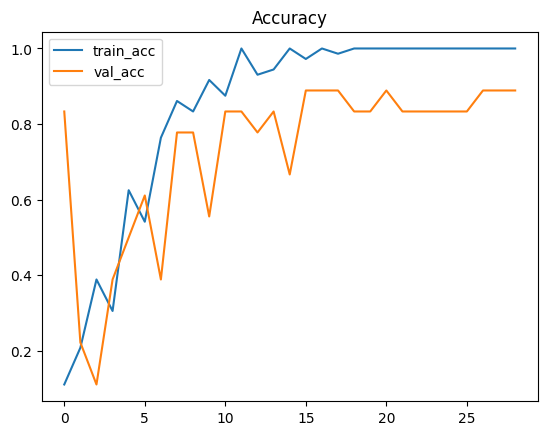

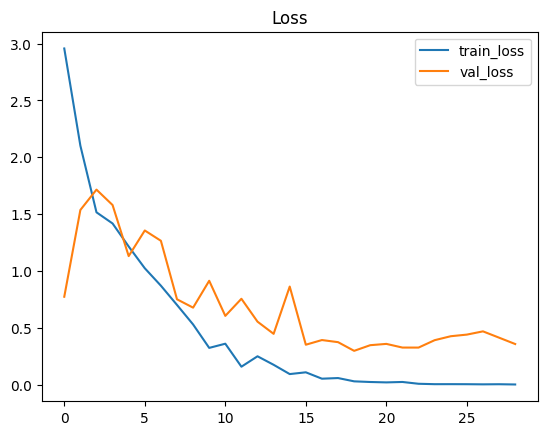

In [47]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()